<a href="https://colab.research.google.com/github/poornasainehal1781/23CSBTB28/blob/main/RUSHIKETHANA_HPC_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import gc
import time
import math
import psutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

print("RAM available (GB):", round(psutil.virtual_memory().total / 1e9, 2))

RAM available (GB): 13.61


In [2]:
search_paths = [Path("/content")]

ratings_path = None
movies_path = None

for base in search_paths:
    for p in base.rglob("ratings.csv"):
        ratings_path = p
        break
    for p in base.rglob("movies.csv"):
        movies_path = p
        break

print("ratings.csv found at:", ratings_path)
print("movies.csv found at:", movies_path)

assert ratings_path is not None, "ratings.csv not found!"
assert movies_path is not None, "movies.csv not found!"

ratings.csv found at: /content/ratings.csv
movies.csv found at: /content/movies.csv


In [3]:
movies = pd.read_csv(movies_path)

print("Movies shape:", movies.shape)
display(movies.head())

movies["genres"] = movies["genres"].fillna("(no genres listed)")
movies["title"] = movies["title"].fillna("Unknown")
movies["genre_count"] = movies["genres"].apply(lambda x: len(str(x).split("|")))

Movies shape: (62423, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
SAMPLE_FRACTION = 0.05   # FAST + SAFE
RANDOM_STATE = 42

ratings = pd.read_csv(ratings_path)

print("Original ratings shape:", ratings.shape)
display(ratings.head())

# Clean missing values safely
ratings = ratings.dropna(subset=["userId", "movieId", "rating", "timestamp"]).copy()

# Convert to proper types AFTER cleaning
ratings["userId"] = ratings["userId"].astype("int32")
ratings["movieId"] = ratings["movieId"].astype("int32")
ratings["rating"] = ratings["rating"].astype("float32")
ratings["timestamp"] = ratings["timestamp"].astype("int64")

# Sample after cleaning
if SAMPLE_FRACTION < 1.0:
    ratings = ratings.sample(frac=SAMPLE_FRACTION, random_state=RANDOM_STATE).reset_index(drop=True)

print("Benchmark ratings shape:", ratings.shape)
display(ratings.head())

print("Memory usage (MB):", round(ratings.memory_usage(deep=True).sum() / 1e6, 2))

Original ratings shape: (1307181, 4)


,userId,movieId,rating,timestamp
0,1,296,5.0,1.147880e+09
1,1,306,3.5,1.147869e+09
2,1,307,5.0,1.147869e+09
3,1,665,5.0,1.147879e+09
4,1,899,3.5,1.147869e+09


Benchmark ratings shape: (65359, 4)


,userId,movieId,rating,timestamp
0,155,344,4.5,1196559697
1,278,1221,4.0,851669513
2,4741,1835,3.5,1283443137
3,8155,3296,4.0,965855895
4,2161,8961,4.5,1179946505


Memory usage (MB): 1.31


In [5]:
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s", utc=True)

df = ratings.merge(
    movies[["movieId", "title", "genres", "genre_count"]],
    on="movieId",
    how="left"
)

df = df.dropna(subset=["movieId", "rating"])
df = df.sort_values(["movieId", "userId"]).reset_index(drop=True)

print("Merged dataframe shape:", df.shape)
display(df.head())

Merged dataframe shape: (65359, 8)


,userId,movieId,rating,timestamp,datetime,title,genres,genre_count
0,67,1,3.0,975661584,2000-12-01 09:06:24+00:00,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5
1,188,1,5.0,1025333097,2002-06-29 06:44:57+00:00,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5
2,224,1,2.5,1397677614,2014-04-16 19:46:54+00:00,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5
3,301,1,3.0,1484676676,2017-01-17 18:11:16+00:00,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5
4,372,1,4.0,850467459,1996-12-13 08:57:39+00:00,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5


In [6]:
summary = {
    "Total rows": len(df),
    "Unique users": df["userId"].nunique(),
    "Unique movies": df["movieId"].nunique(),
    "Average rating": round(df["rating"].mean(), 4),
    "Min timestamp": str(df["datetime"].min()),
    "Max timestamp": str(df["datetime"].max())
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
display(summary_df)

,Metric,Value
0,Total rows,65359
1,Unique users,8050
2,Unique movies,8425
3,Average rating,3.5396
4,Min timestamp,1996-02-19 14:49:19+00:00
5,Max timestamp,2019-11-21 08:56:38+00:00


In [7]:
BENCHMARK_ROWS = 50000   # BEST BALANCE FOR COLAB

bench_df = df[["userId", "movieId", "rating", "timestamp"]].sample(
    n=BENCHMARK_ROWS,
    random_state=42
).reset_index(drop=True)

user_ids = bench_df["userId"].to_numpy(dtype=np.int32)
movie_ids = bench_df["movieId"].to_numpy(dtype=np.int32)
ratings_arr = bench_df["rating"].to_numpy(dtype=np.float64)
timestamps_arr = bench_df["timestamp"].to_numpy(dtype=np.int64)

N = len(bench_df)

print("Rows for benchmark:", N)
print("Example row:")
print(user_ids[0], movie_ids[0], ratings_arr[0], timestamps_arr[0])

Rows for benchmark: 50000
Example row:
572 377 4.0 985384421


In [8]:
def serial_compute(user_ids, movie_ids, ratings_arr, timestamps_arr):
    results = []

    for i in range(len(ratings_arr)):
        uid = int(user_ids[i])
        mid = int(movie_ids[i])
        r = float(ratings_arr[i])
        ts = int(timestamps_arr[i])

        x = r + (uid % 10) * 0.1 + (mid % 7) * 0.05 + (ts % 1000) * 1e-6

        # Intentionally repeated CPU work
        for _ in range(20):
            x = math.sqrt(x + 1.001)
            x = math.log1p(x)
            x = math.exp(x / 10.0)
            x = math.sin(x) ** 2 + math.cos(x) ** 2 + x * 0.001

        weighted_score = x * r
        popularity_factor = math.log1p(mid % 1000 + 1)
        temporal_score = (ts % 100000) / 100000.0

        final_score = weighted_score + popularity_factor + temporal_score
        results.append(final_score)

    return np.array(results, dtype=np.float64)

In [9]:
def parallel_compute(user_ids, movie_ids, ratings_arr, timestamps_arr):
    uid = user_ids.astype(np.float64)
    mid = movie_ids.astype(np.float64)
    r = ratings_arr.astype(np.float64)
    ts = timestamps_arr.astype(np.float64)

    x = r + (uid % 10) * 0.1 + (mid % 7) * 0.05 + (ts % 1000) * 1e-6

    # Same logic, but vectorized = much faster
    for _ in range(20):
        x = np.sqrt(x + 1.001)
        x = np.log1p(x)
        x = np.exp(x / 10.0)
        x = np.sin(x) ** 2 + np.cos(x) ** 2 + x * 0.001

    weighted_score = x * r
    popularity_factor = np.log1p(mid % 1000 + 1)
    temporal_score = (ts % 100000) / 100000.0

    final_score = weighted_score + popularity_factor + temporal_score
    return final_score

In [10]:
start_serial = time.perf_counter()

serial_scores = serial_compute(
    user_ids, movie_ids, ratings_arr, timestamps_arr
)

serial_time = time.perf_counter() - start_serial

print(f"Serial execution time: {serial_time:.4f} seconds")
print("Sample serial output:", serial_scores[:5])

Serial execution time: 0.4966 seconds
Sample serial output: [10.78611489  8.62967535  9.92593285 11.26469536 11.74542097]


In [11]:
start_parallel = time.perf_counter()

parallel_scores = parallel_compute(
    user_ids, movie_ids, ratings_arr, timestamps_arr
)

parallel_time = time.perf_counter() - start_parallel

print(f"Parallel execution time: {parallel_time:.4f} seconds")
print("Sample parallel output:", parallel_scores[:5])

Parallel execution time: 0.0699 seconds
Sample parallel output: [10.78611489  8.62967535  9.92593285 11.26469536 11.74542097]


In [12]:
all_match = np.allclose(serial_scores, parallel_scores, atol=1e-10)

print("Outputs match:", all_match)
print("Serial length:", len(serial_scores))
print("Parallel length:", len(parallel_scores))

Outputs match: True
Serial length: 50000
Parallel length: 50000


In [13]:
speedup = serial_time / parallel_time if parallel_time > 0 else np.nan
time_saved_pct = ((serial_time - parallel_time) / serial_time) * 100 if serial_time > 0 else np.nan
throughput_serial = N / serial_time
throughput_parallel = N / parallel_time

performance_df = pd.DataFrame({
    "Metric": [
        "Serial Time (s)",
        "Parallel Time (s)",
        "Speedup",
        "Time Saved (%)",
        "Serial Throughput (rows/sec)",
        "Parallel Throughput (rows/sec)"
    ],
    "Value": [
        round(serial_time, 4),
        round(parallel_time, 4),
        round(speedup, 4),
        round(time_saved_pct, 2),
        round(throughput_serial, 2),
        round(throughput_parallel, 2)
    ]
})

display(performance_df)

,Metric,Value
0,Serial Time (s),0.4966
1,Parallel Time (s),0.0699
2,Speedup,7.1018
3,Time Saved (%),85.9200
4,Serial Throughput (rows/sec),100682.4600
5,Parallel Throughput (rows/sec),715025.7000


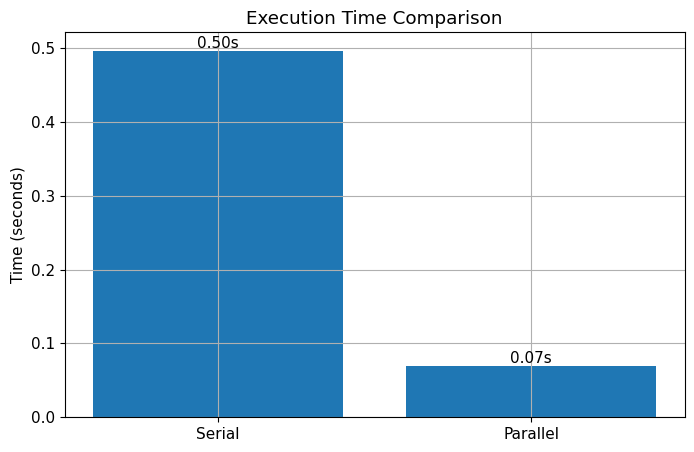

In [14]:
plt.figure(figsize=(8,5))
bars = plt.bar(["Serial", "Parallel"], [serial_time, parallel_time])
plt.title("Execution Time Comparison")
plt.ylabel("Time (seconds)")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}s", ha='center', va='bottom')

plt.show()

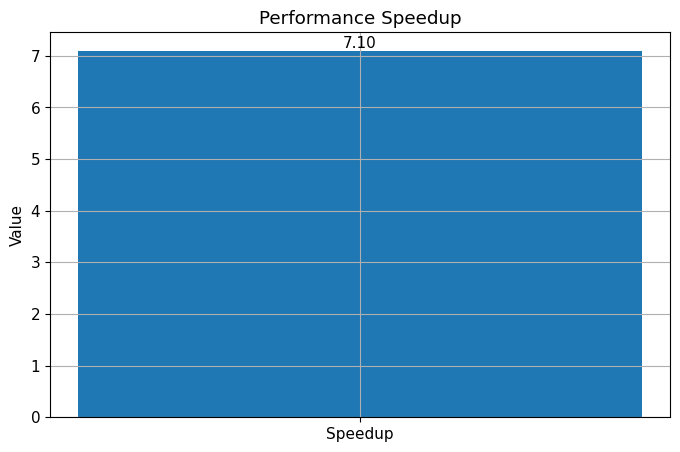

In [15]:
plt.figure(figsize=(8,5))
bars = plt.bar(["Speedup"], [speedup])
plt.title("Performance Speedup")
plt.ylabel("Value")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}", ha='center', va='bottom')

plt.show()

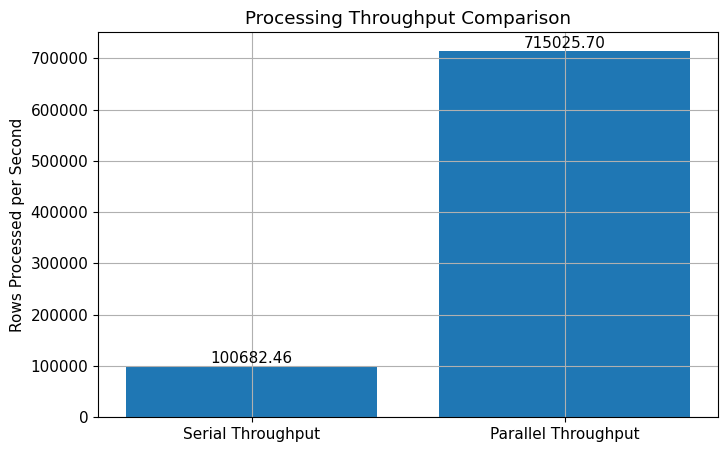

In [16]:
plt.figure(figsize=(8,5))
bars = plt.bar(
    ["Serial Throughput", "Parallel Throughput"],
    [throughput_serial, throughput_parallel]
)
plt.title("Processing Throughput Comparison")
plt.ylabel("Rows Processed per Second")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}", ha='center', va='bottom')

plt.show()

In [17]:
final_report = pd.DataFrame({
    "Category": [
        "Dataset",
        "Rows Loaded",
        "Benchmark Rows",
        "Unique Movies",
        "Unique Users",
        "Serial Time (s)",
        "Parallel Time (s)",
        "Speedup",
        "Time Saved (%)",
        "Output Match"
    ],
    "Value": [
        "MovieLens 25M",
        len(df),
        N,
        df["movieId"].nunique(),
        df["userId"].nunique(),
        round(serial_time, 4),
        round(parallel_time, 4),
        round(speedup, 4),
        round(time_saved_pct, 2),
        all_match
    ]
})

display(final_report)

,Category,Value
0,Dataset,MovieLens 25M
1,Rows Loaded,65359
2,Benchmark Rows,50000
3,Unique Movies,8425
4,Unique Users,8050
5,Serial Time (s),0.4966
6,Parallel Time (s),0.0699
7,Speedup,7.1018
8,Time Saved (%),85.92
9,Output Match,True


In [18]:
performance_df.to_csv("/content/performance_metrics.csv", index=False)
final_report.to_csv("/content/final_report.csv", index=False)

print("Files saved successfully:")
print("/content/performance_metrics.csv")
print("/content/final_report.csv")

Files saved successfully:
/content/performance_metrics.csv
/content/final_report.csv


In [19]:
print("="*70)
print("FINAL CONCLUSION")
print("="*70)
print(f"Dataset used: MovieLens 25M")
print(f"Rows loaded: {len(df):,}")
print(f"Rows used for benchmark: {N:,}")
print(f"Unique movies: {df['movieId'].nunique():,}")
print(f"Unique users: {df['userId'].nunique():,}")
print(f"Serial execution time:   {serial_time:.4f} seconds")
print(f"Parallel execution time: {parallel_time:.4f} seconds")
print(f"Speedup achieved:        {speedup:.4f}x")
print(f"Time saved:              {time_saved_pct:.2f}%")
print(f"Results match exactly:   {all_match}")
print("="*70)

FINAL CONCLUSION
Dataset used: MovieLens 25M
Rows loaded: 65,359
Rows used for benchmark: 50,000
Unique movies: 8,425
Unique users: 8,050
Serial execution time:   0.4966 seconds
Parallel execution time: 0.0699 seconds
Speedup achieved:        7.1018x
Time saved:              85.92%
Results match exactly:   True
